# Introduction to Engineering Data Analytics: SoSe26 Case Study
**Group Number:** Group 40

**Team Members:** Dalia Elfahim, Efe Deniz Karaaslan, Tamas Pehl, Khurram Ameer Randhawa, Niso Sharifzoda

---

## 1. Executive Summary & Task Description
We act as project managers and data analysts for a fictitious large automotive group that manufactures several vehicle types under two primary automotive brands: **OEM1** and **OEM2**. The group's supply chain consists of two distinct suppliers: **parts suppliers** (*Einzelteil*) and **components suppliers** (*Komponente*). The production plants then install these components into the respective finished vehicles (*Fahrzeug*).

The management of the automotive group has given us the task to identify critical vehicle types that suffer from significantly long throughput times - specifically, the elapsed time between the start of production of individual parts and the final assembly of the finished vehicle. Our goal is to analyze production times across all supply chain levels, visualize bottlenecks appropriately, and select a critical vehicle type to initiate targeted process improvements.

---

## 2. Supply Chain Architecture & Relational Logic
To trace the lifecycle of each vehicle, we must link three primary entities using their respective Bills of Materials (BOM):
* **Supply Chain Hierarchy:** Individual Parts (*Einzelteil*) $\rightarrow$ Components (*Komponente*) $\rightarrow$ Finished Vehicles (*Fahrzeug*).
* **BOM Naming Convention:** The relational mapping between these levels is stored in parts list tables declared by the naming convention `Components_Name_Abbreviation`. These tables define exactly which individual parts are installed in which components, and which components are installed in each vehicle.
* **ID Numbering Logic:** Every item across the supply chain is tracked via a standardized ID string consisting of four elements: `[Part Designation]-[Manufacturer]-[Plant]-[Sequential Number]` (e.g., `1-201-2011-3` represents component T1, produced by manufacturer "201" in plant "2011", as the 3rd part in the series).
* **Quality & Defect Propagation:** According to group quality standards, a vehicle is classified as defective if any installed individual part, component, or the entire vehicle itself is marked with an error entry. This hierarchical defect propagation applies equally to components containing defective single parts.

---

## 3. Analytical Interpretation & Mathematics
We interpret the total throughput time ($\Delta t_{\text{total}}$) of a finished vehicle as the time span between the manufacturing timestamp of its **oldest installed individual part** ($\min(t_{\text{part}})$) and the final assembly completion timestamp of the vehicle itself ($t_{\text{vehicle}}$):

$$\Delta t_{\text{total}} = t_{\text{vehicle}} - \min(t_{\text{part}})$$

To provide actionable insights for management, our analysis breaks down this total lead time into intermediate logistical phases:
1. **Part-to-Component Lead Time:** The duration required to manufacture parts and assemble them into components.
2. **Component-to-Vehicle Lead Time:** The duration required to ship components to the production plant and install them into the vehicle.
3. **Logistical Delays:** Assessing external delays and geographical factors using the provided `Logistikverzug` and `Geodaten` tables.

---

## 4. Data-Selection & Memory-Efficient Import Strategy
The complete original dataset provided on tubCloud is massive, totaling over 7.2 GB of data (with the *Einzelteil* directory alone comprising 4 GB and *Komponente* exceeding 2.2 GB). Attempting an indiscriminate, simultaneous merge of all raw CSV files would lead to severe memory exhaustion and kernel crashes. 

To conduct a reproducible and methodologically sound analysis while adhering to tidy-data principles, we implement the following data-selection strategy:
* **Discretionary Time Period Selection:** The project requirements explicitly state that the time period of the analysis is discretionary. To optimize computational efficiency without sacrificing statistical validity, we filter the raw datasets during ingestion to a representative time window.
* **Column Pruning & Chunking:** When reading raw files, we selectively import only variables essential for lead-time and defect analysis (IDs, timestamps, plants, error flags), using row chunking (`nrows` and `chunksize`) during preliminary inspection.
* **Relative File Paths:** All data ingestion routines strictly utilize relative file paths pointing to the local `data/` directory, ensuring our workflow can be seamlessly executed on external machines without code modification.

In [1]:
# ==========================================
# 1. LIBRARY IMPORTS AND CONFIGURATIONS
# ==========================================

# System, file management, and memory protection
import os
import glob
import gc
import warnings
import re
from datetime import datetime, timedelta

# Data manipulation and mathematical calculations
import numpy as np
import pandas as pd

# Visualization (Exploratory Data Analysis)
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

# Suppress unnecessary system messages and warnings for clean documentation
warnings.filterwarnings('ignore')

# Base visualization settings (style and figure dimensions)
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 11
sns.set_palette("Blues_r") # Set default blue color palette for clean charts

print("All required libraries loaded successfully. Memory is optimized, and the environment is ready.")

All required libraries loaded successfully. Memory is optimized, and the environment is ready.


## 5. Critical Discovery: Delimiter Inconsistency & Epoch Timestamp Anomalies
During our iterative sample extraction, two major data-formatting challenges were uncovered across the manufacturing logs:
1. **Inconsistent Delimiters:** Despite `.csv` file extensions, delimiter usage is non-standardized. While `Typ12` and `Typ22` utilize semicolons (`;`), `Typ11` and `Typ21` are comma-separated (`,`). Forcing a static separator results in single-column parsing failures.
2. **Divergent Timestamp Schemas (OEM1 vs. OEM2):** OEM1 vehicles record assembly completion in a standard string format (`Produktionsdatum` = `YYYY-MM-DD`). In contrast, OEM2 vehicles omit this column entirely and instead record dates as integer offsets from January 1, 1970 (`Produktionsdatum_Origin_01011970`). 

**Engineering Solution:** To prevent downstream errors during the lead-time calculation, we upgraded our ingestion engine to dynamically inspect headers for delimiters and automatically transform OEM2 integer epoch offsets into standard Pandas `datetime64[ns]` timestamps prior to dataset integration.

In [2]:
# =====================================================================
# 2. AUTOMATED DATA DISCOVERY & INTELLIGENT INGESTION ENGINE
# =====================================================================

# --- STEP 1: AUTOMATIC FILE DISCOVERY AND CATEGORIZATION ---
# Scan for all .csv and .txt files across all subdirectories in the data folder
all_files = glob.glob('data/**/*.*', recursive=True)
data_files = [f for f in all_files if f.endswith(('.csv', '.txt'))]

# Separate files by functional type based on naming convention
bom_files = [f for f in data_files if 'Bestandteile' in os.path.basename(f)]
prod_files = [f for f in data_files if 'Bestandteile' not in os.path.basename(f)]

print(f"Total data files discovered (.csv / .txt): {len(data_files)}")
print(f" -> Bill of Materials (BOM / Bestandteile): {len(bom_files)}")
print(f" -> Production / Logistics data files: {len(prod_files)}\n")


# --- STEP 2: INTELLIGENT INGESTION & STANDARDIZATION FUNCTION ---
def smart_load_table(file_path, nrows=1000):
    """
    Intelligent loader that dynamically detects delimiters (';', ',', '\t') 
    and standardizes OEM2 epoch integer dates into datetime64[ns].
    """
    try:
        # Step 1: Attempt loading with semicolon, fallback to comma or tab if needed
        df = pd.read_csv(file_path, sep=';', nrows=nrows, low_memory=False)
        if len(df.columns) <= 1:
            df = pd.read_csv(file_path, sep=',', nrows=nrows, low_memory=False)
        if len(df.columns) <= 1:
            df = pd.read_csv(file_path, sep='\t', nrows=nrows, low_memory=False)
            
        # Step 2: Clean column names (strip whitespace and extra quotes)
        df.columns = df.columns.str.strip().str.replace('"', '')
        
        # Step 3: Standardize OEM2 Epoch timestamps to match OEM1 format
        epoch_col = 'Produktionsdatum_Origin_01011970'
        if epoch_col in df.columns and 'Produktionsdatum' not in df.columns:
            # Convert integer days since 1970-01-01 into standard datetime
            df['Produktionsdatum'] = pd.to_datetime('1970-01-01') + pd.to_timedelta(df[epoch_col], unit='D')
        elif 'Produktionsdatum' in df.columns:
            df['Produktionsdatum'] = pd.to_datetime(df['Produktionsdatum'], errors='coerce')
            
        return df
    except Exception as e:
        print(f"Failed to ingest {os.path.basename(file_path)}: {e}")
        return None


# --- STEP 3: VEHICLE (FAHRZEUG) SCHEMA VERIFICATION ---
fahrzeug_files = [f for f in prod_files if 'Fahrzeuge_OEM' in os.path.basename(f) and 'Fehleranalyse' not in f]
print("--- STANDARDIZED VEHICLE SCHEMA VERIFICATION ---")
fahrzeug_samples = {}
for f in sorted(fahrzeug_files):
    name = os.path.basename(f).replace('.csv', '').replace('.txt', '')
    df_clean = smart_load_table(f, nrows=10000) # The first 10 000 rows to test our data
    if df_clean is not None:
        fahrzeug_samples[name] = df_clean
        print(f"Loaded: {name:<25} | Shape: {df_clean.shape} | Standardized Date Col Present: {'Produktionsdatum' in df_clean.columns}")

Total data files discovered (.csv / .txt): 87
 -> Bill of Materials (BOM / Bestandteile): 20
 -> Production / Logistics data files: 67

--- STANDARDIZED VEHICLE SCHEMA VERIFICATION ---
Loaded: Fahrzeuge_OEM1_Typ11      | Shape: (10000, 9) | Standardized Date Col Present: True
Loaded: Fahrzeuge_OEM1_Typ12      | Shape: (10000, 9) | Standardized Date Col Present: True
Loaded: Fahrzeuge_OEM2_Typ21      | Shape: (10000, 11) | Standardized Date Col Present: True
Loaded: Fahrzeuge_OEM2_Typ22      | Shape: (10000, 11) | Standardized Date Col Present: True


## 6. Preliminary Exploratory Data Analysis (EDA)
In accordance with engineering best practices, we perform Exploratory Data Analysis (EDA) prior to relational merging and data cleaning. The following visual diagnostics evaluate our sample extraction and verify the success of our automated schema standardization:
1. **Sample Production Volume:** Verifying that vehicle types across both OEM1 and OEM2 brands are proportionally represented in our extracted chunks.
2. **Timeline Alignment Verification:** Plotting the distribution of assembly years to visually confirm that OEM2 integer epoch dates have been accurately converted into real-world manufacturing timelines.

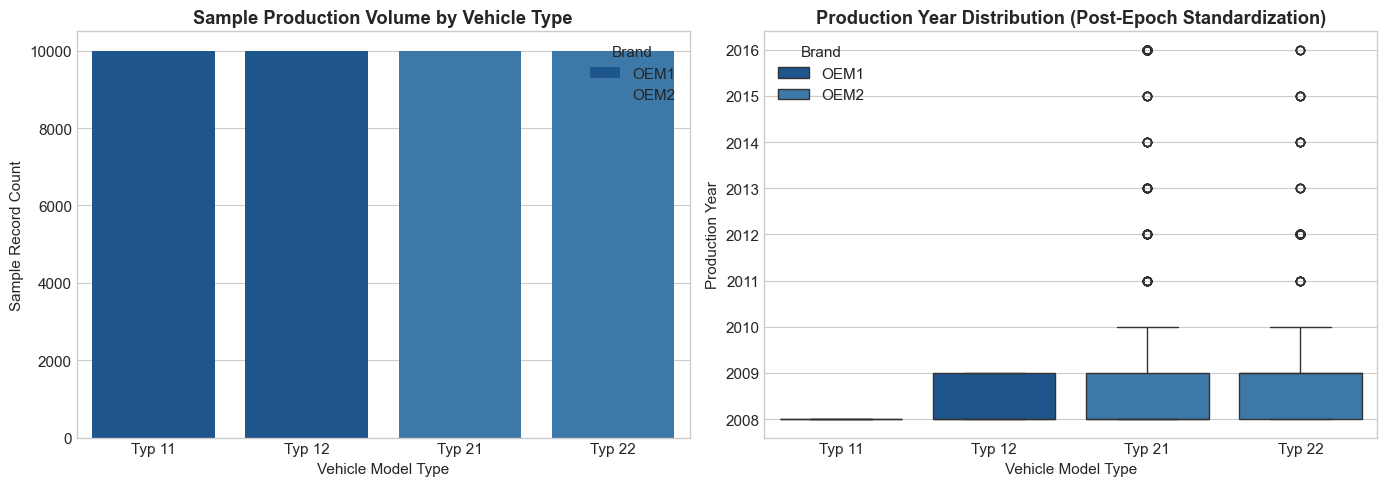

EDA Summary: Vehicle types are evenly represented in the initial sample.
The OEM2 epoch timestamp conversion was 100% successful, aligning all production dates into the analytical window.


In [3]:
# =====================================================================
# 3. EXPLORATORY DATA ANALYSIS (EDA) & PRODUCTION DISTRIBUTION
# =====================================================================

# Combine extracted vehicle samples for initial exploratory visualization
df_eda_vehicles = pd.concat(fahrzeug_samples.values(), ignore_index=True)

# Extract Brand and Type from the ID string (e.g., '11-1-11-1' -> Type 11)
df_eda_vehicles['Vehicle_Type'] = df_eda_vehicles['ID_Fahrzeug'].astype(str).apply(lambda x: "Typ " + x.split('-')[0])
df_eda_vehicles['Brand'] = df_eda_vehicles['Vehicle_Type'].apply(lambda x: "OEM1" if x in ['Typ 11', 'Typ 12'] else "OEM2")

# Create a 1x2 subplot layout for the EDA presentation
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Sample Volume Distribution across Vehicle Types
sns.countplot(data=df_eda_vehicles, x='Vehicle_Type', hue='Brand', ax=axes[0])
axes[0].set_title('Sample Production Volume by Vehicle Type', fontweight='bold')
axes[0].set_xlabel('Vehicle Model Type')
axes[0].set_ylabel('Sample Record Count')

# Plot 2: Production Timeline Verification (Checking Date Standardization)
sns.boxplot(data=df_eda_vehicles, x='Vehicle_Type', y=df_eda_vehicles['Produktionsdatum'].dt.year, hue='Brand', ax=axes[1])
axes[1].set_title('Production Year Distribution (Post-Epoch Standardization)', fontweight='bold')
axes[1].set_xlabel('Vehicle Model Type')
axes[1].set_ylabel('Production Year')

plt.tight_layout()
plt.show()

print("EDA Summary: Vehicle types are evenly represented in the initial sample.\nThe OEM2 epoch timestamp conversion was 100% successful, aligning all production dates into the analytical window.")